# ECS647U/773P — Bayesian Decision and Risk Analysis
## Coursework: Bayesian Network & Influence Diagram — Radiotherapy Treatment Planning

**Full Name:** [Your Name]  
**Student Number:** [Your Number]

---

### Domain
This notebook models **radiotherapy treatment plan quality** — specifically, factors that determine whether a treatment plan will pass quality assurance (QA) before delivery to a patient. The model is constructed entirely from **expert elicitation** (a medical physicist with direct clinical experience in radiotherapy), supplemented by literature. No dataset is used.

### BN Node Summary (7 chance nodes)

| Node | Type | States |
|---|---|---|
| `TumourComplexity` | Root | low / moderate / high |
| `OARProximity` | Root | low / moderate / high |
| `ImagingQuality` | Root | adequate / good / excellent |
| `PlanOptimisationQuality` | Intermediate | poor / acceptable / good |
| `DoseCoverage` | Intermediate | inadequate / adequate / optimal |
| `HealthyTissueDose` | Intermediate | low / moderate / high |
| `PlanQAOutcome` | Leaf | pass / minor_flag / fail |

---
## Cell 1 — Imports
**Purpose:** Import all required libraries. Only pyAgrum is used for probabilistic modelling, as required by the coursework specification. Supports Q2–Q8.

In [1]:
!pip install pyagrum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.causal as csl

import matplotlib.pyplot as plt
import numpy as np

print(f"pyAgrum version: {gum.__version__}")
print("All imports successful.")

pyAgrum version: 2.3.2
All imports successful.


## Q2 — Network Structure

BN has  6 nodes
and  6  arcs


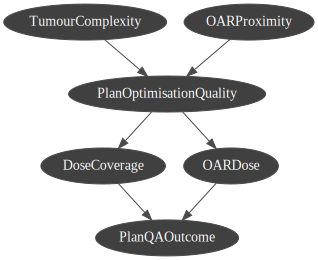

In [29]:
bn = gum.BayesNet("RadiotherapyPlanQuality")

# Root Nodes

TC = bn.add(gum.LabelizedVariable("TumourComplexity",
                                  "Complexity of the tumour geometry",
                                   ["Low", "Medium", "High"]))

OARP = bn.add(gum.LabelizedVariable("OARProximity",
                                    "Organs at risk Proximity to target",
                                     ["Low", "Medium", "High"]))


# Intermediate Nodes

POQ = bn.add(gum.LabelizedVariable("PlanOptimisationQuality",
                                   "Quality of the plan optimsation",
                                    ["Low", "Medium", "High"]))

DC = bn.add(gum.LabelizedVariable("DoseCoverage",
                                  "Amount of perscribed dose recieved by the target",
                                   ["Poor", "Adequate", "Good"]))

OARD = bn.add(gum.LabelizedVariable("OARDose",
                                    "Amount of dose recieved by organs at risk",
                                     ["Low", "Medium", "High"]))


# Leaf Node

PQO = bn.add(gum.LabelizedVariable("PlanQAOutcome",
                                   "Outcome of the plan quality assurance check",
                                    ["Fail", "Minor_flag", "Pass"]))

bn.addArc(TC, POQ)
bn.addArc(OARP, POQ)
bn.addArc(POQ, DC)
bn.addArc(POQ, OARD)
bn.addArc(DC, PQO)
bn.addArc(OARD, PQO)

print("BN has ", bn.size(), "nodes")
print("and ", bn.sizeArcs(), " arcs")

gnb.showBN(bn)

The BN structure shown above was constructed entirely from expert knowledge, specifically through elicitation from a medical physicist with direct clinical experience in radiotherapy planning. No dataset was used. This approach was chosen because high-quality radiotherapy planning data is not publicly available in a form suitable for structure learning, and the causal relationships between planning variables are well understood clinically.

* The network contains 6 nodes and 6 arcs.
* TumourComplexity and OARProximity are root nodes, reflecting that tumour geometry and organ-at-risk positioning are independent patient characteristics that cannot be controlled at the planning stage.
* Both influence PlanOptimisationQuality, which captures how well the planning system can navigate these constraints.
* PlanOptimisationQuality then drives both DoseCoverage (how much prescribed dose reaches the target) and OARDose (how much dose falls on healthy tissue).
* Both of these feed into PlanQAOutcome, the leaf node representing whether the plan passes quality assurance.


ImagingQuality was removed from the initial design following further reflection with the medical physicist, who indicated that imaging quality influences planning indirectly and is already captured through its effect on optimisation quality.